Uncomment the savefig() commands to save the figures (I commented them out)

In [2]:
import pandas as pd
df = pd.read_csv('clean_daily_temperatures.csv')
df.head()

C:\Users\Maike\AppData\Local\Temp\ipykernel_20544\3522621364.py:2: DtypeWarning: Columns (0: TAVG_ATTRIBUTES) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('clean_daily_temperatures.csv')


,station_id,date,latitude,longitude,elevation_m,station_name,TMAX,TMAX_ATTRIBUTES,TMIN,TMIN_ATTRIBUTES,TAVG,TAVG_ATTRIBUTES,year,month,day,TMAX_C,TMIN_C,TAVG_C
0,USC00040136,1970-01-01,32.8358,-116.7774,516.6,"ALPINE, CA US",178.0,",,0",17.0,",,0",NaN,NaN,1970,1,1,17.8,1.7,97.5
1,USC00040136,1970-01-02,32.8358,-116.7774,516.6,"ALPINE, CA US",144.0,",,0",78.0,",,0",NaN,NaN,1970,1,2,14.4,7.8,111.0
2,USC00040136,1970-01-03,32.8358,-116.7774,516.6,"ALPINE, CA US",156.0,",,0",-11.0,",,0",NaN,NaN,1970,1,3,15.6,-1.1,72.5
3,USC00040136,1970-01-04,32.8358,-116.7774,516.6,"ALPINE, CA US",133.0,",,0",11.0,",,0",NaN,NaN,1970,1,4,13.3,1.1,72.0
4,USC00040136,1970-01-05,32.8358,-116.7774,516.6,"ALPINE, CA US",161.0,",,0",-11.0,",,0",NaN,NaN,1970,1,5,16.1,-1.1,75.0


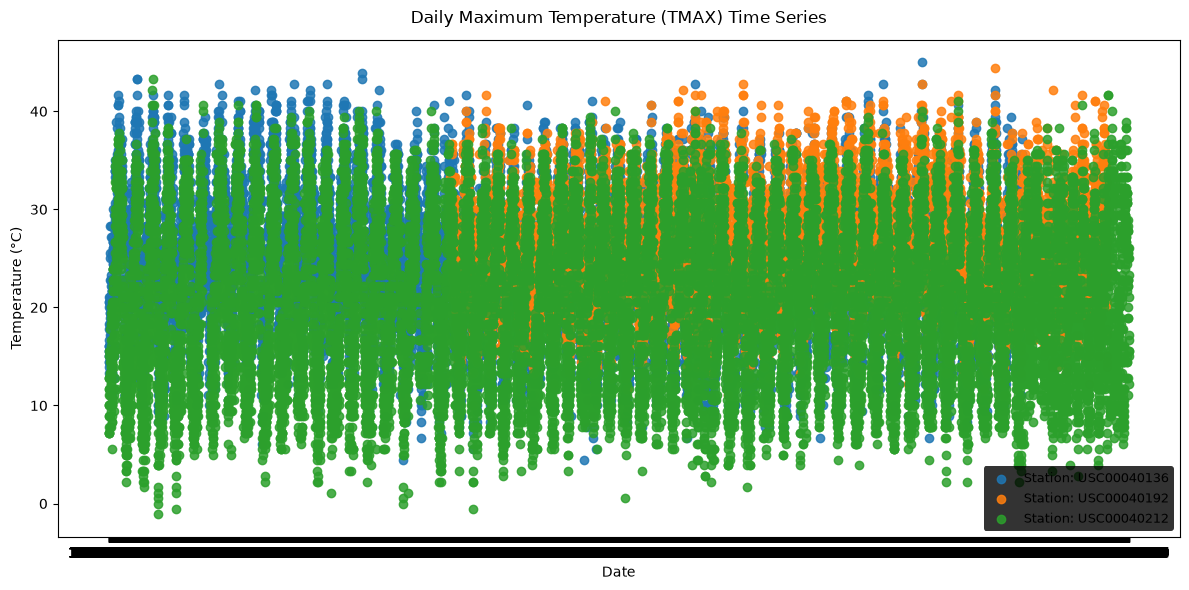

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

# Initialize figure with high print quality resolution
plt.figure(figsize=(12, 6), dpi=100)

# Filter for the first 3 unique stations
subset = df[df['station_id'].isin(df['station_id'].unique()[:3])]

# Plot each station with refined line weights and transparency
for station, data in subset.groupby('station_id'):
    plt.scatter(
        data['date'],
        data['TMAX_C'],
        label=f'Station: {station}',
        alpha=0.85,
    )

# Formatting titles and labels
plt.title(
    'Daily Maximum Temperature (TMAX) Time Series', fontsize=12, pad=12
)
plt.xlabel('Date', fontsize=10)
plt.ylabel('Temperature (°C)', fontsize=10)

# Clean grid styling and layout adjustments
plt.legend(frameon=True, facecolor='black', edgecolor='none', fontsize=9)
plt.tight_layout()

# Save at high print quality
#plt.savefig(
#    'Figure_TimeSeries_TMAX.png', dpi=300, bbox_inches='tight', facecolor='black'
#)
plt.show()

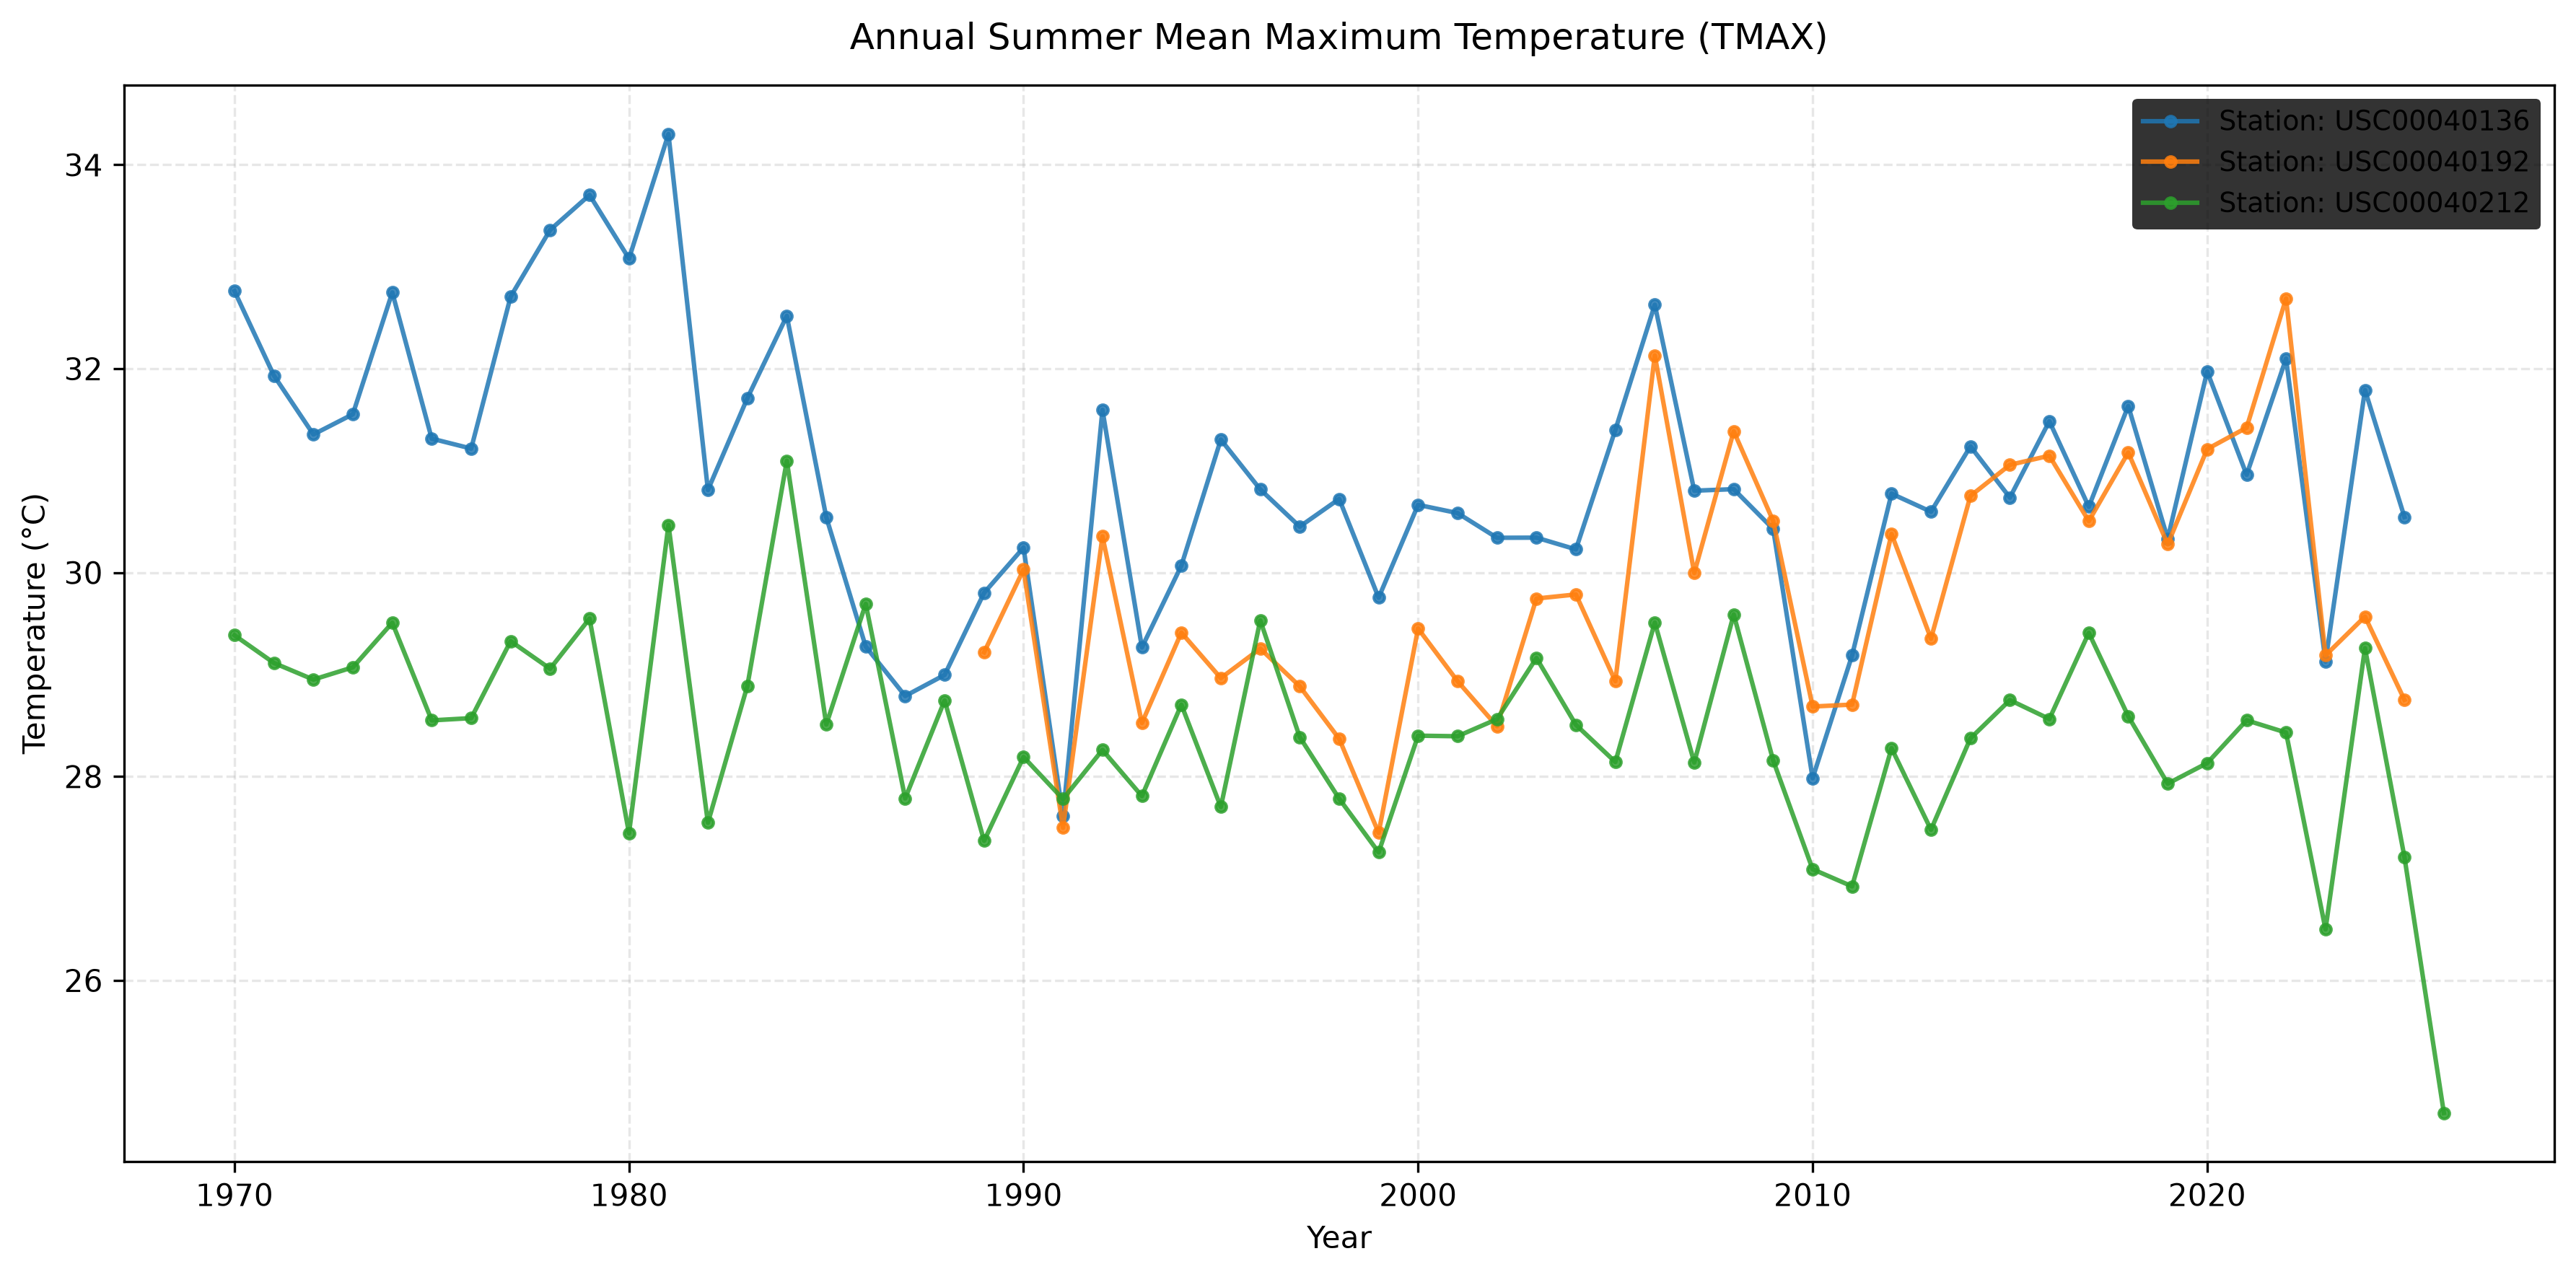

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# Enable dark background for publication styling
#plt.style.use('dark_background')

# Compute summer means (June-September)
summer_means = (
    df[df['month'].isin([6, 7, 8, 9])]
    .groupby(['year', 'station_id'])[['TMAX_C', 'TMIN_C']]
    .mean()
    .reset_index()
)

# Initialize figure with high print quality resolution
plt.figure(figsize=(12, 6), dpi=300)

# Plot each station's annual summer mean TMAX with refined styling
for station in df['station_id'].unique()[:3]:
    st_data = summer_means[summer_means['station_id'] == station]
    plt.plot(
        st_data['year'],
        st_data['TMAX_C'],
        label=f'Station: {station}',
        linewidth=1.5,
        marker='o',
        markersize=3.5,
        alpha=0.85,
    )

# Formatting titles and labels
plt.title(
    'Annual Summer Mean Maximum Temperature (TMAX)', fontsize=12, pad=12
)
plt.xlabel('Year', fontsize=10)
plt.ylabel('Temperature (°C)', fontsize=10)

# Clean grid styling and layout adjustments
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(frameon=True, facecolor='black', edgecolor='none', fontsize=9)
plt.tight_layout()

# Save at high print quality
#plt.savefig(
#    'Figure_Summer_Mean_TMAX.png', dpi=300, bbox_inches='tight', facecolor='black'
#)
plt.show()

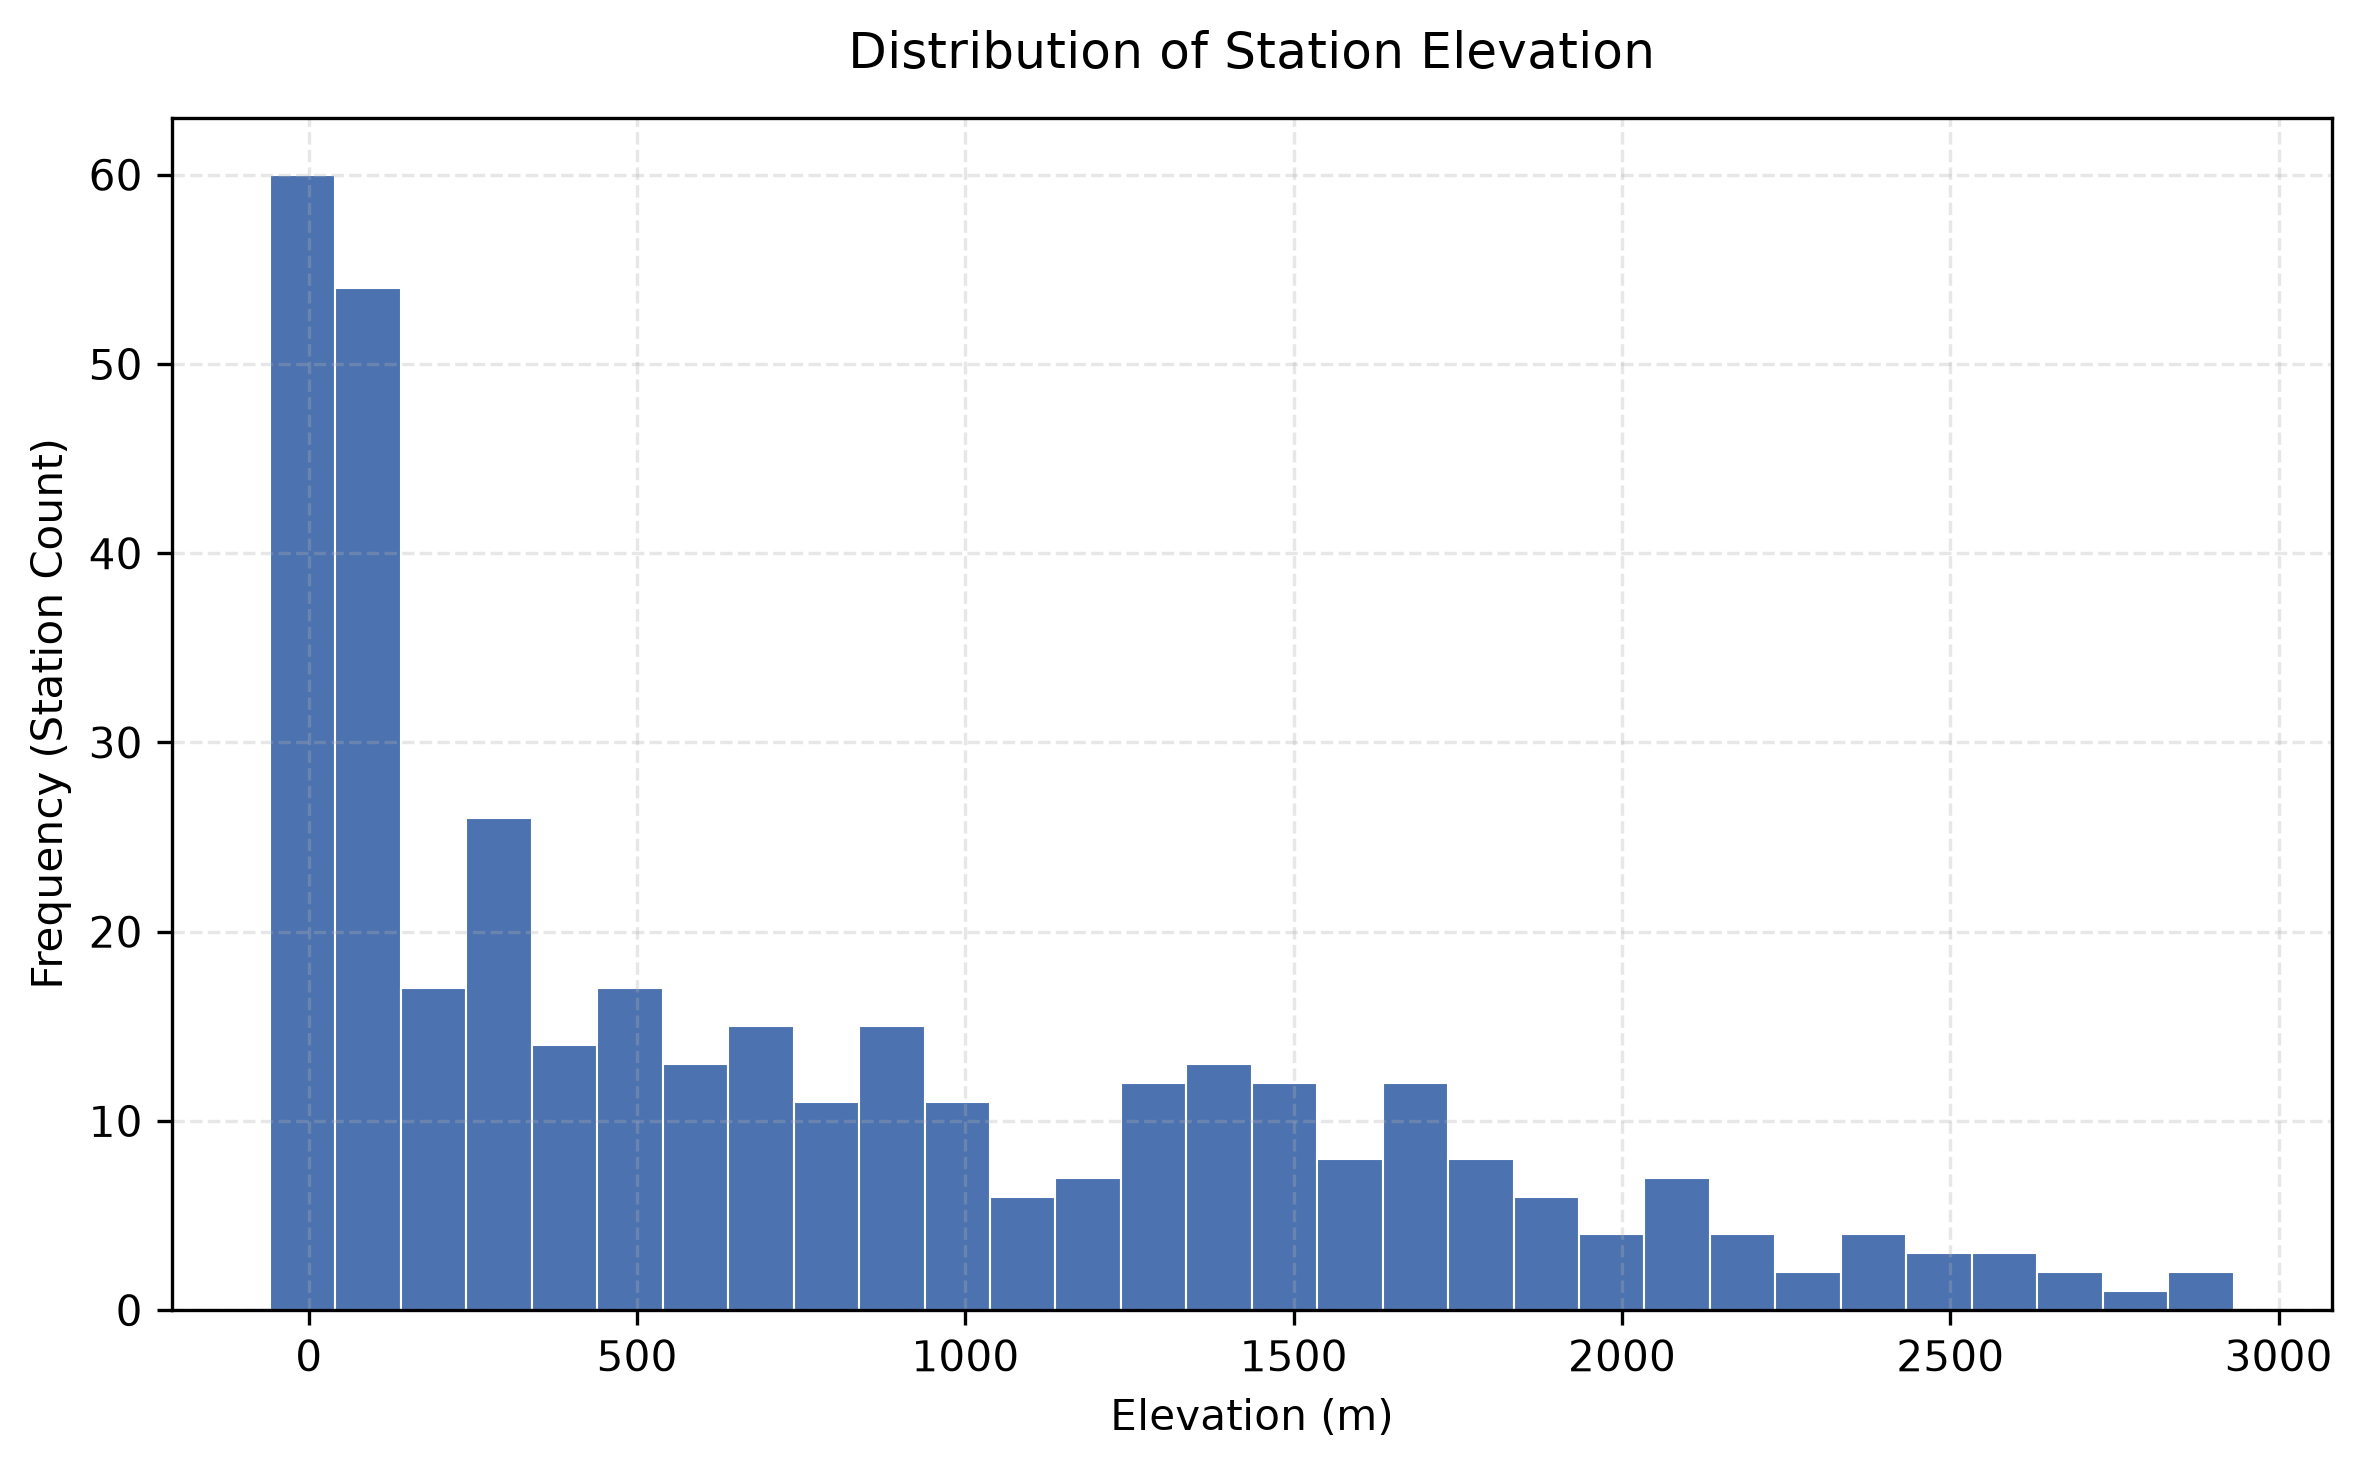

In [8]:
import matplotlib.pyplot as plt
import pandas as pd

# Initialize figure with high print quality resolution
plt.figure(figsize=(8, 5), dpi=300)

# Plot histogram of unique station elevations with refined styling
df[['station_id', 'elevation_m']].drop_duplicates()['elevation_m'].hist(
    bins=30, color='#4c72b0', edgecolor='white', lw=0.5
)

# Formatting titles and labels
plt.title('Distribution of Station Elevation', fontsize=12, pad=12)
plt.xlabel('Elevation (m)', fontsize=10)
plt.ylabel('Frequency (Station Count)', fontsize=10)

# Clean grid styling and layout adjustments
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

# Save at high print quality
plt.savefig(
    'Figure_Elevation_Distribution.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='black',
)
plt.show()

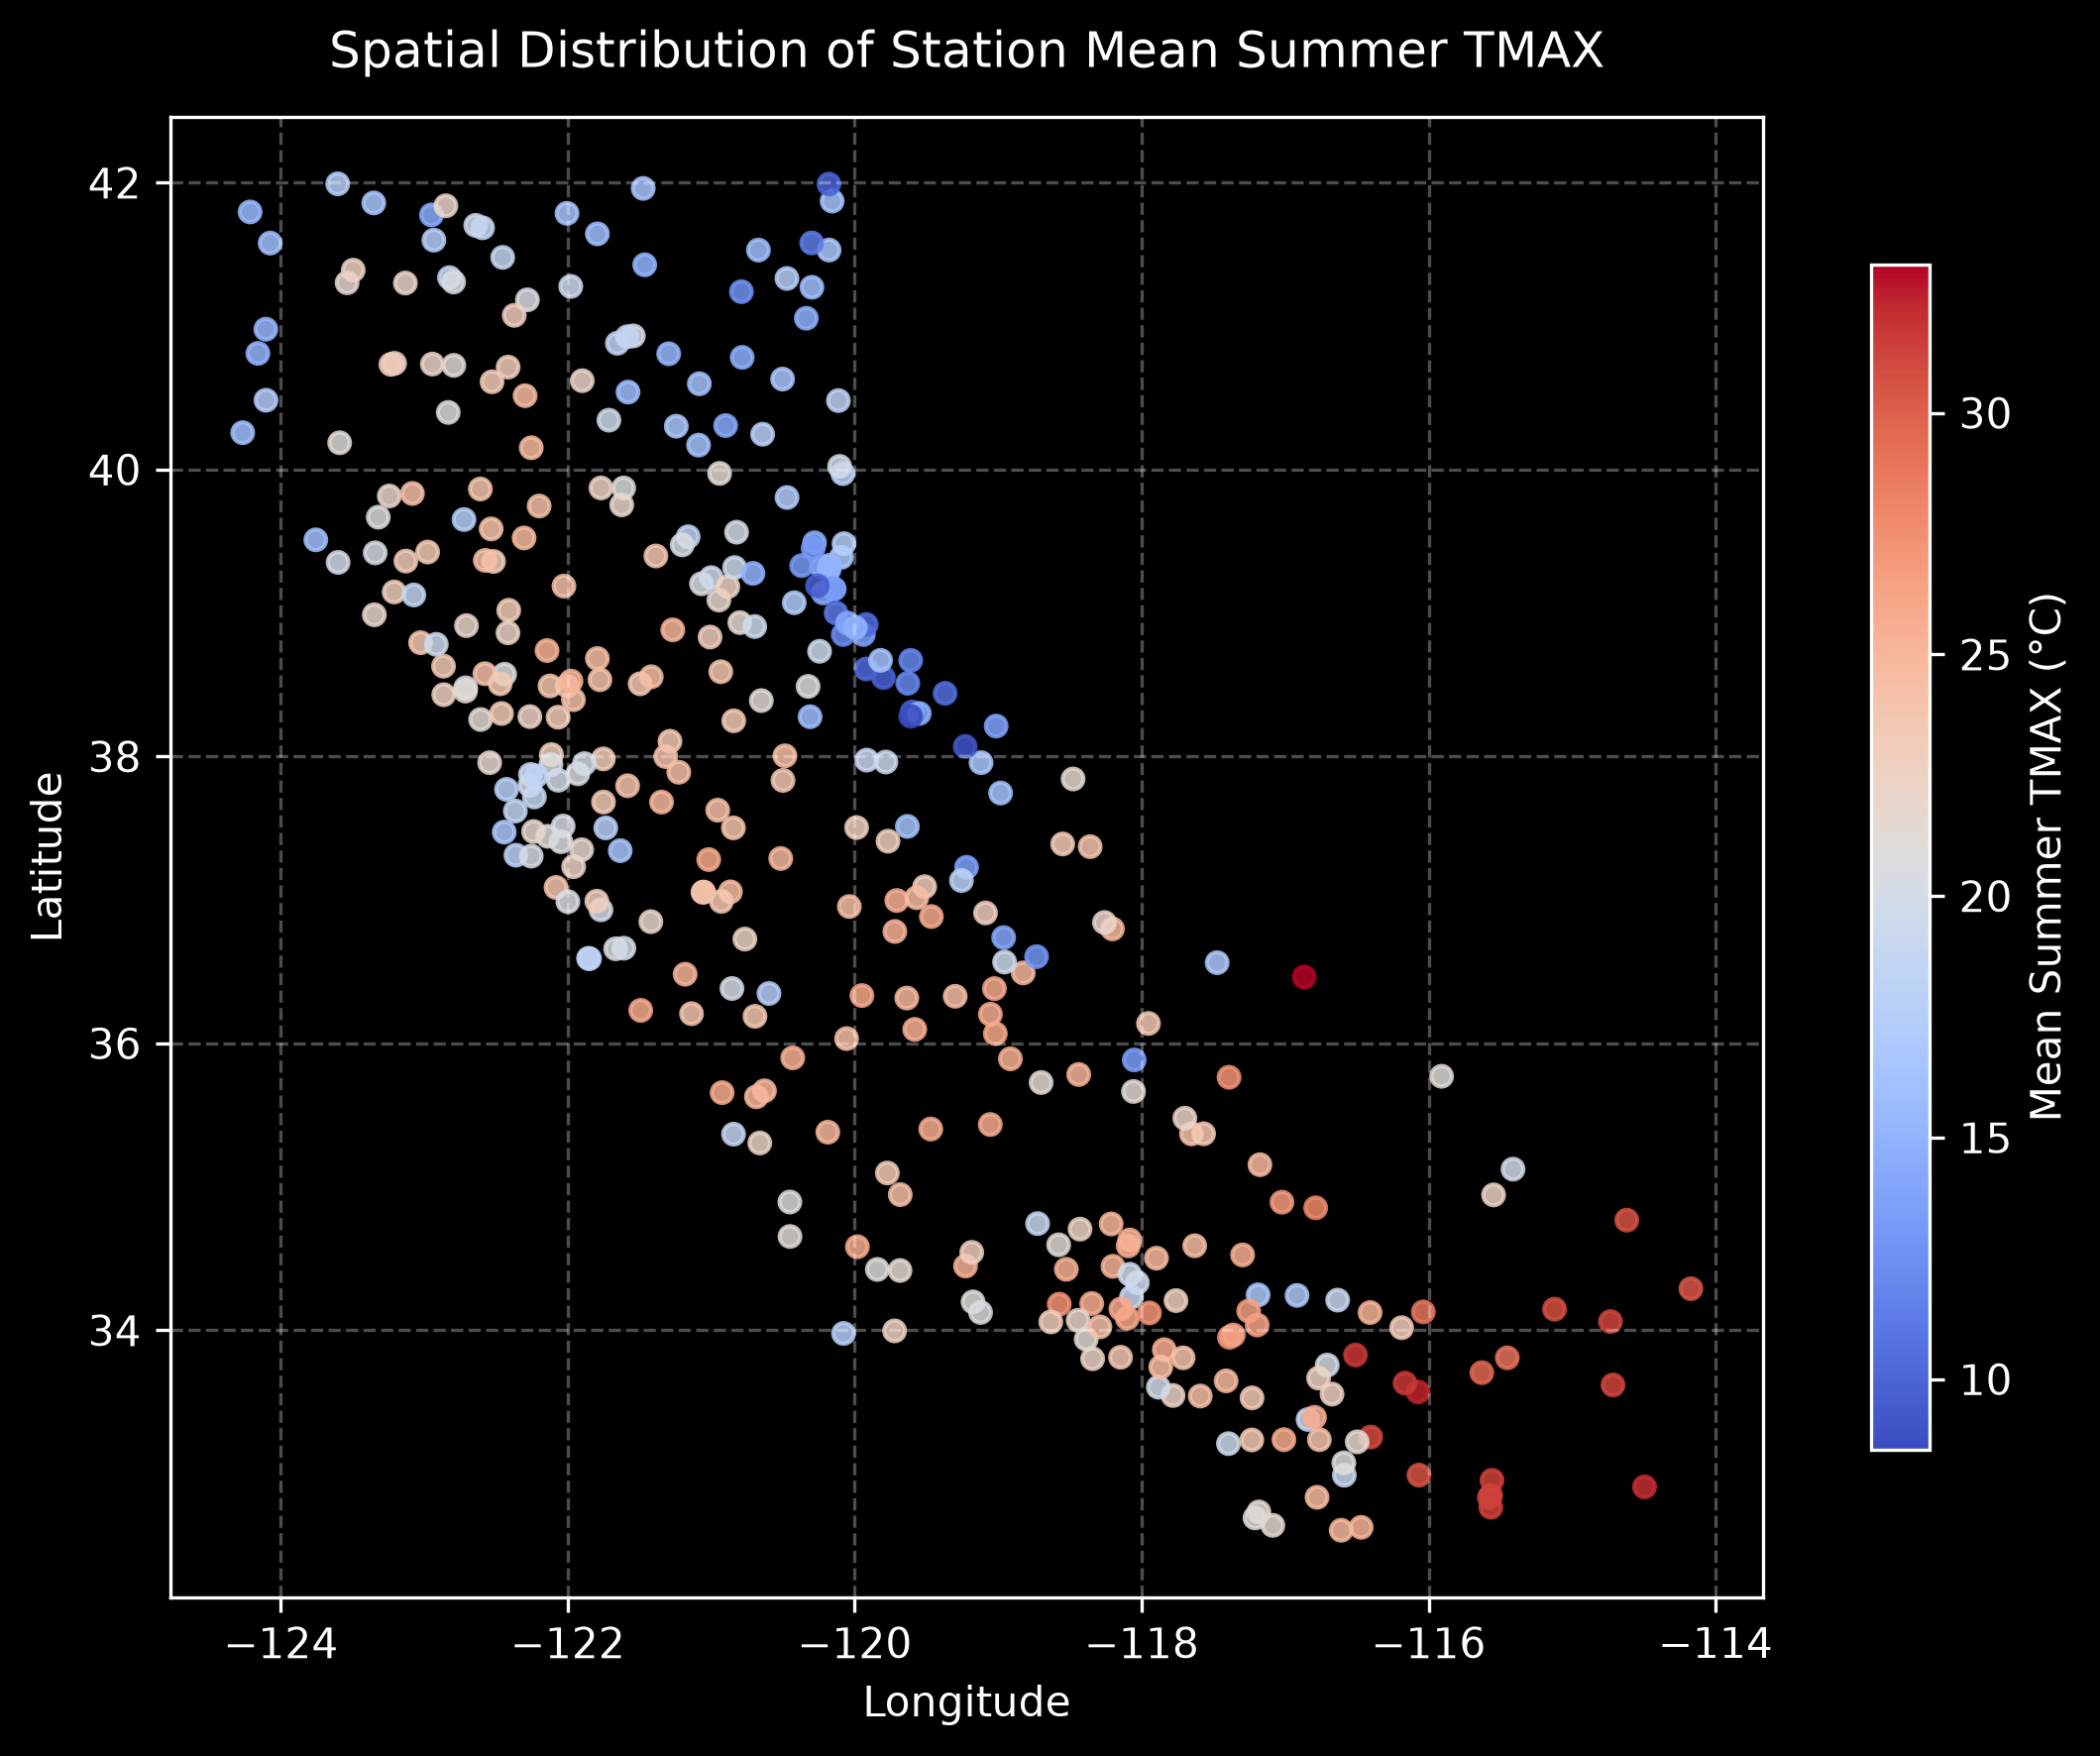

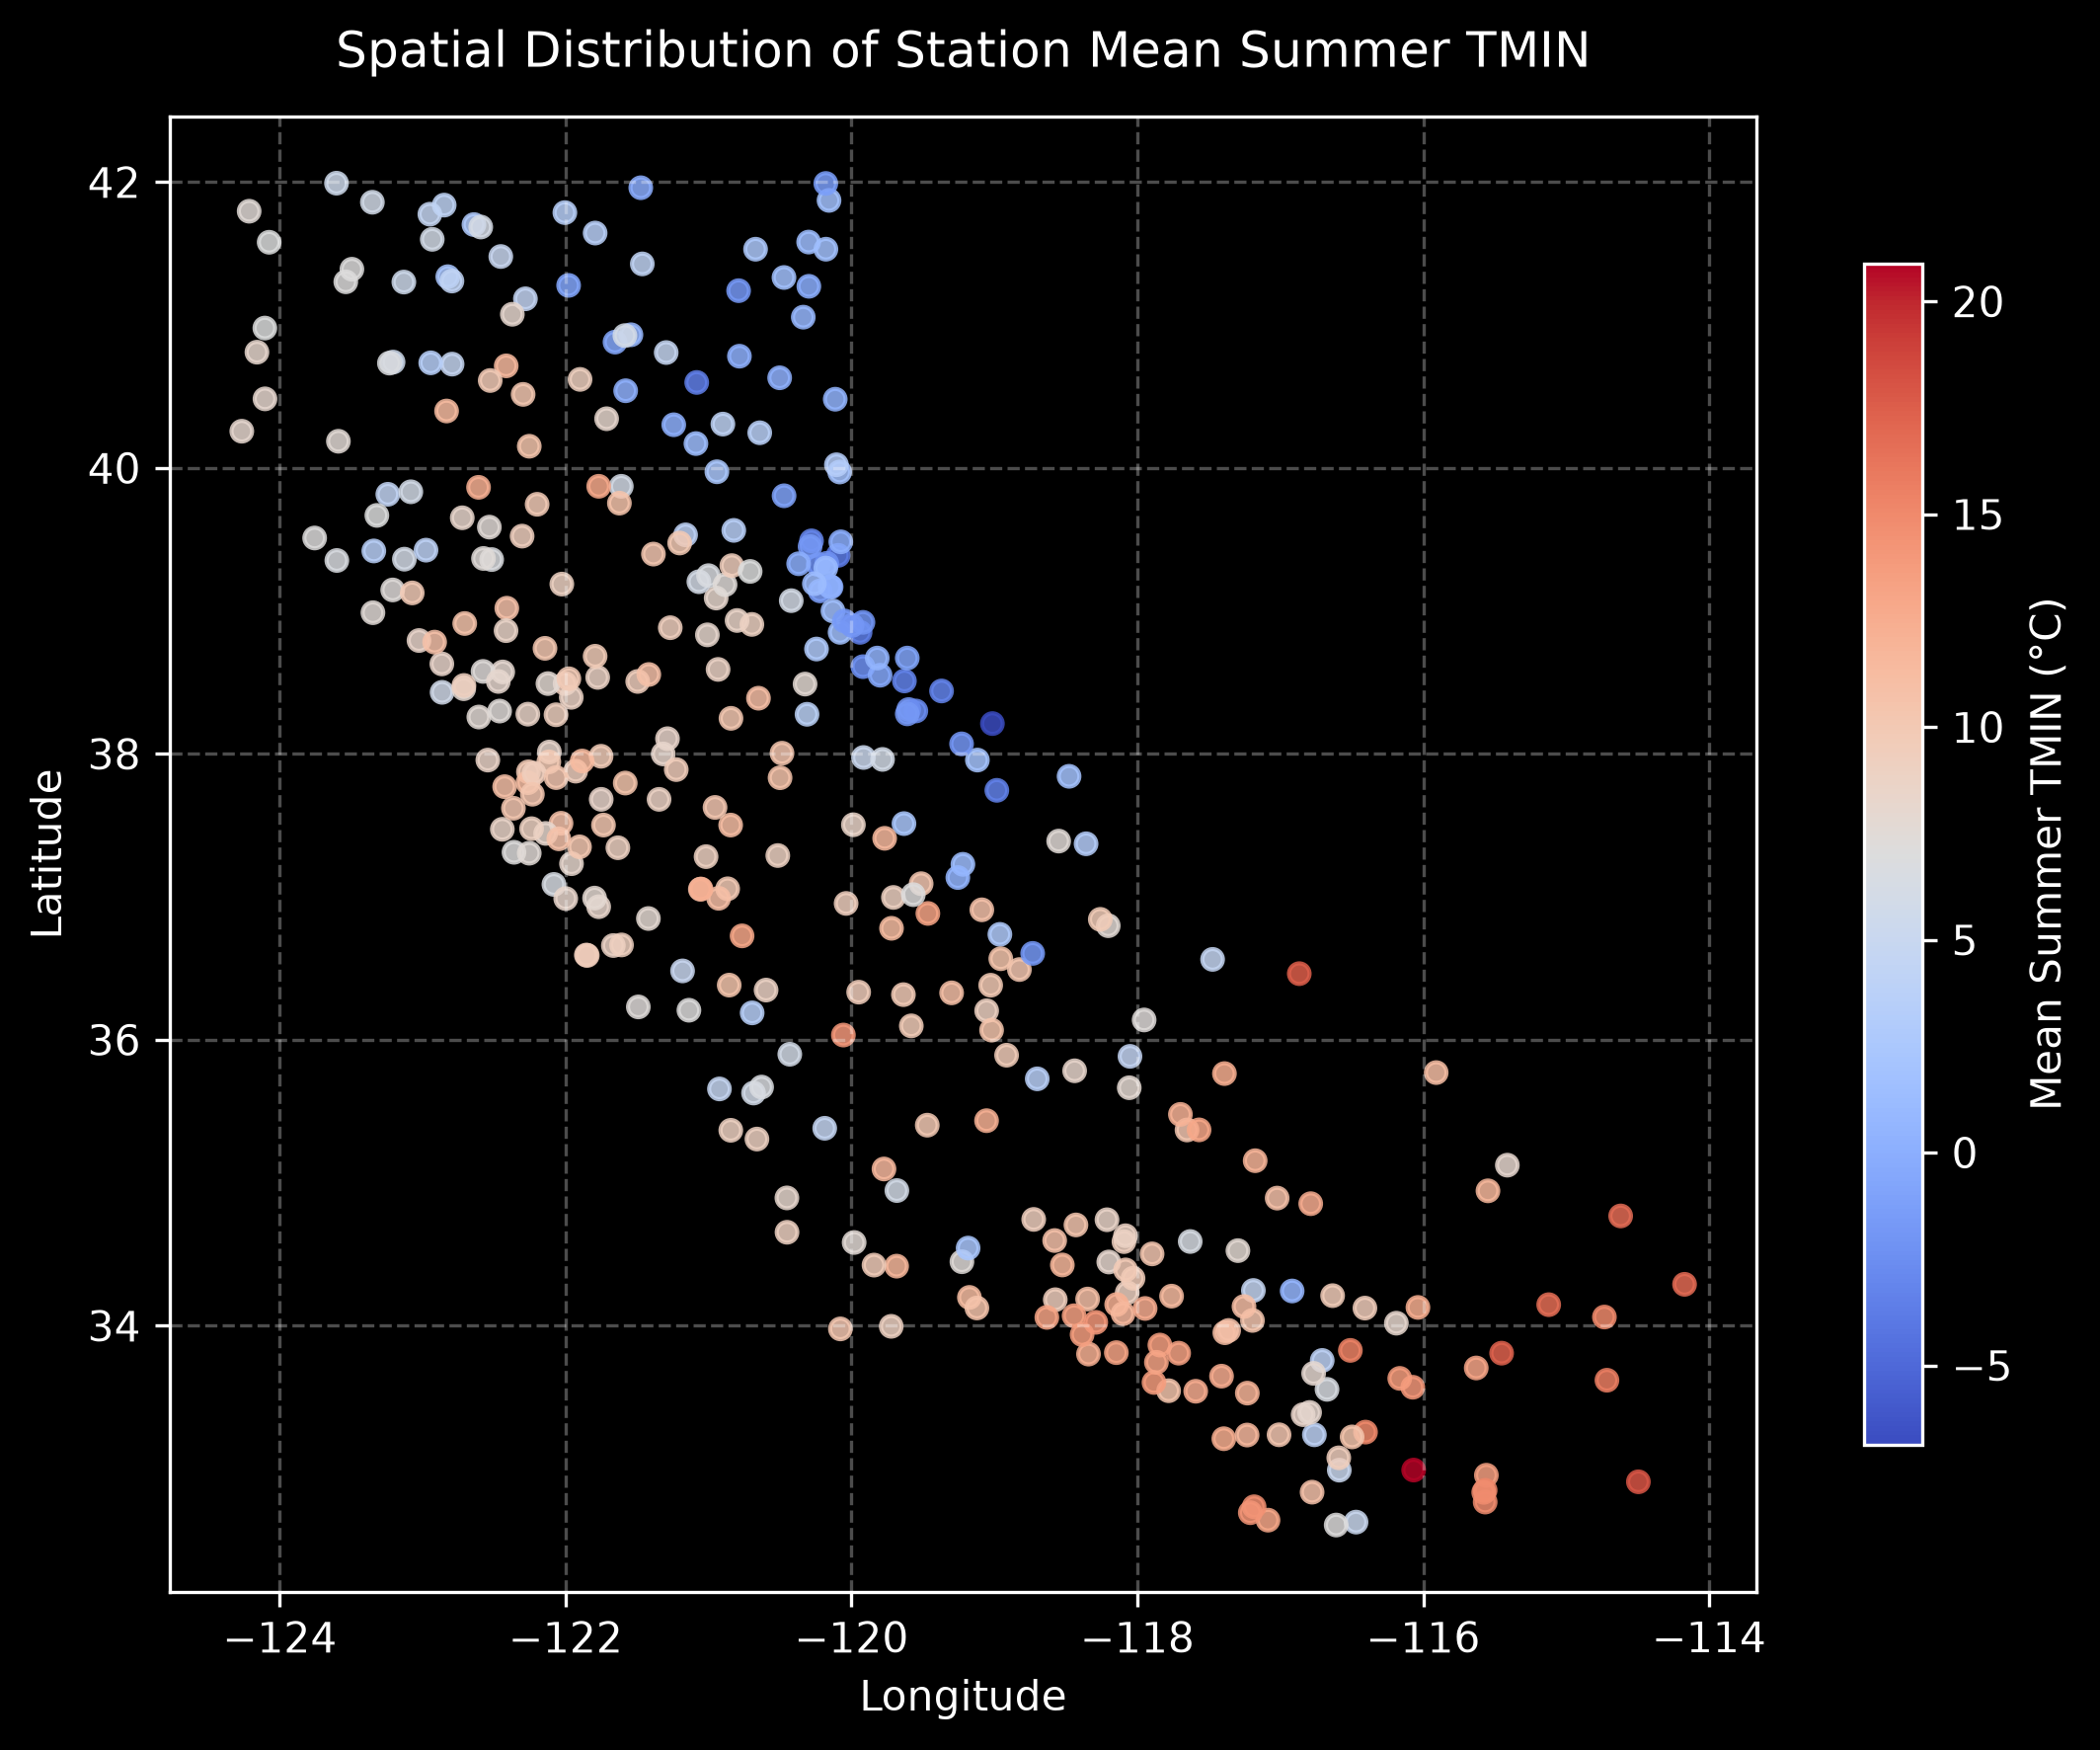

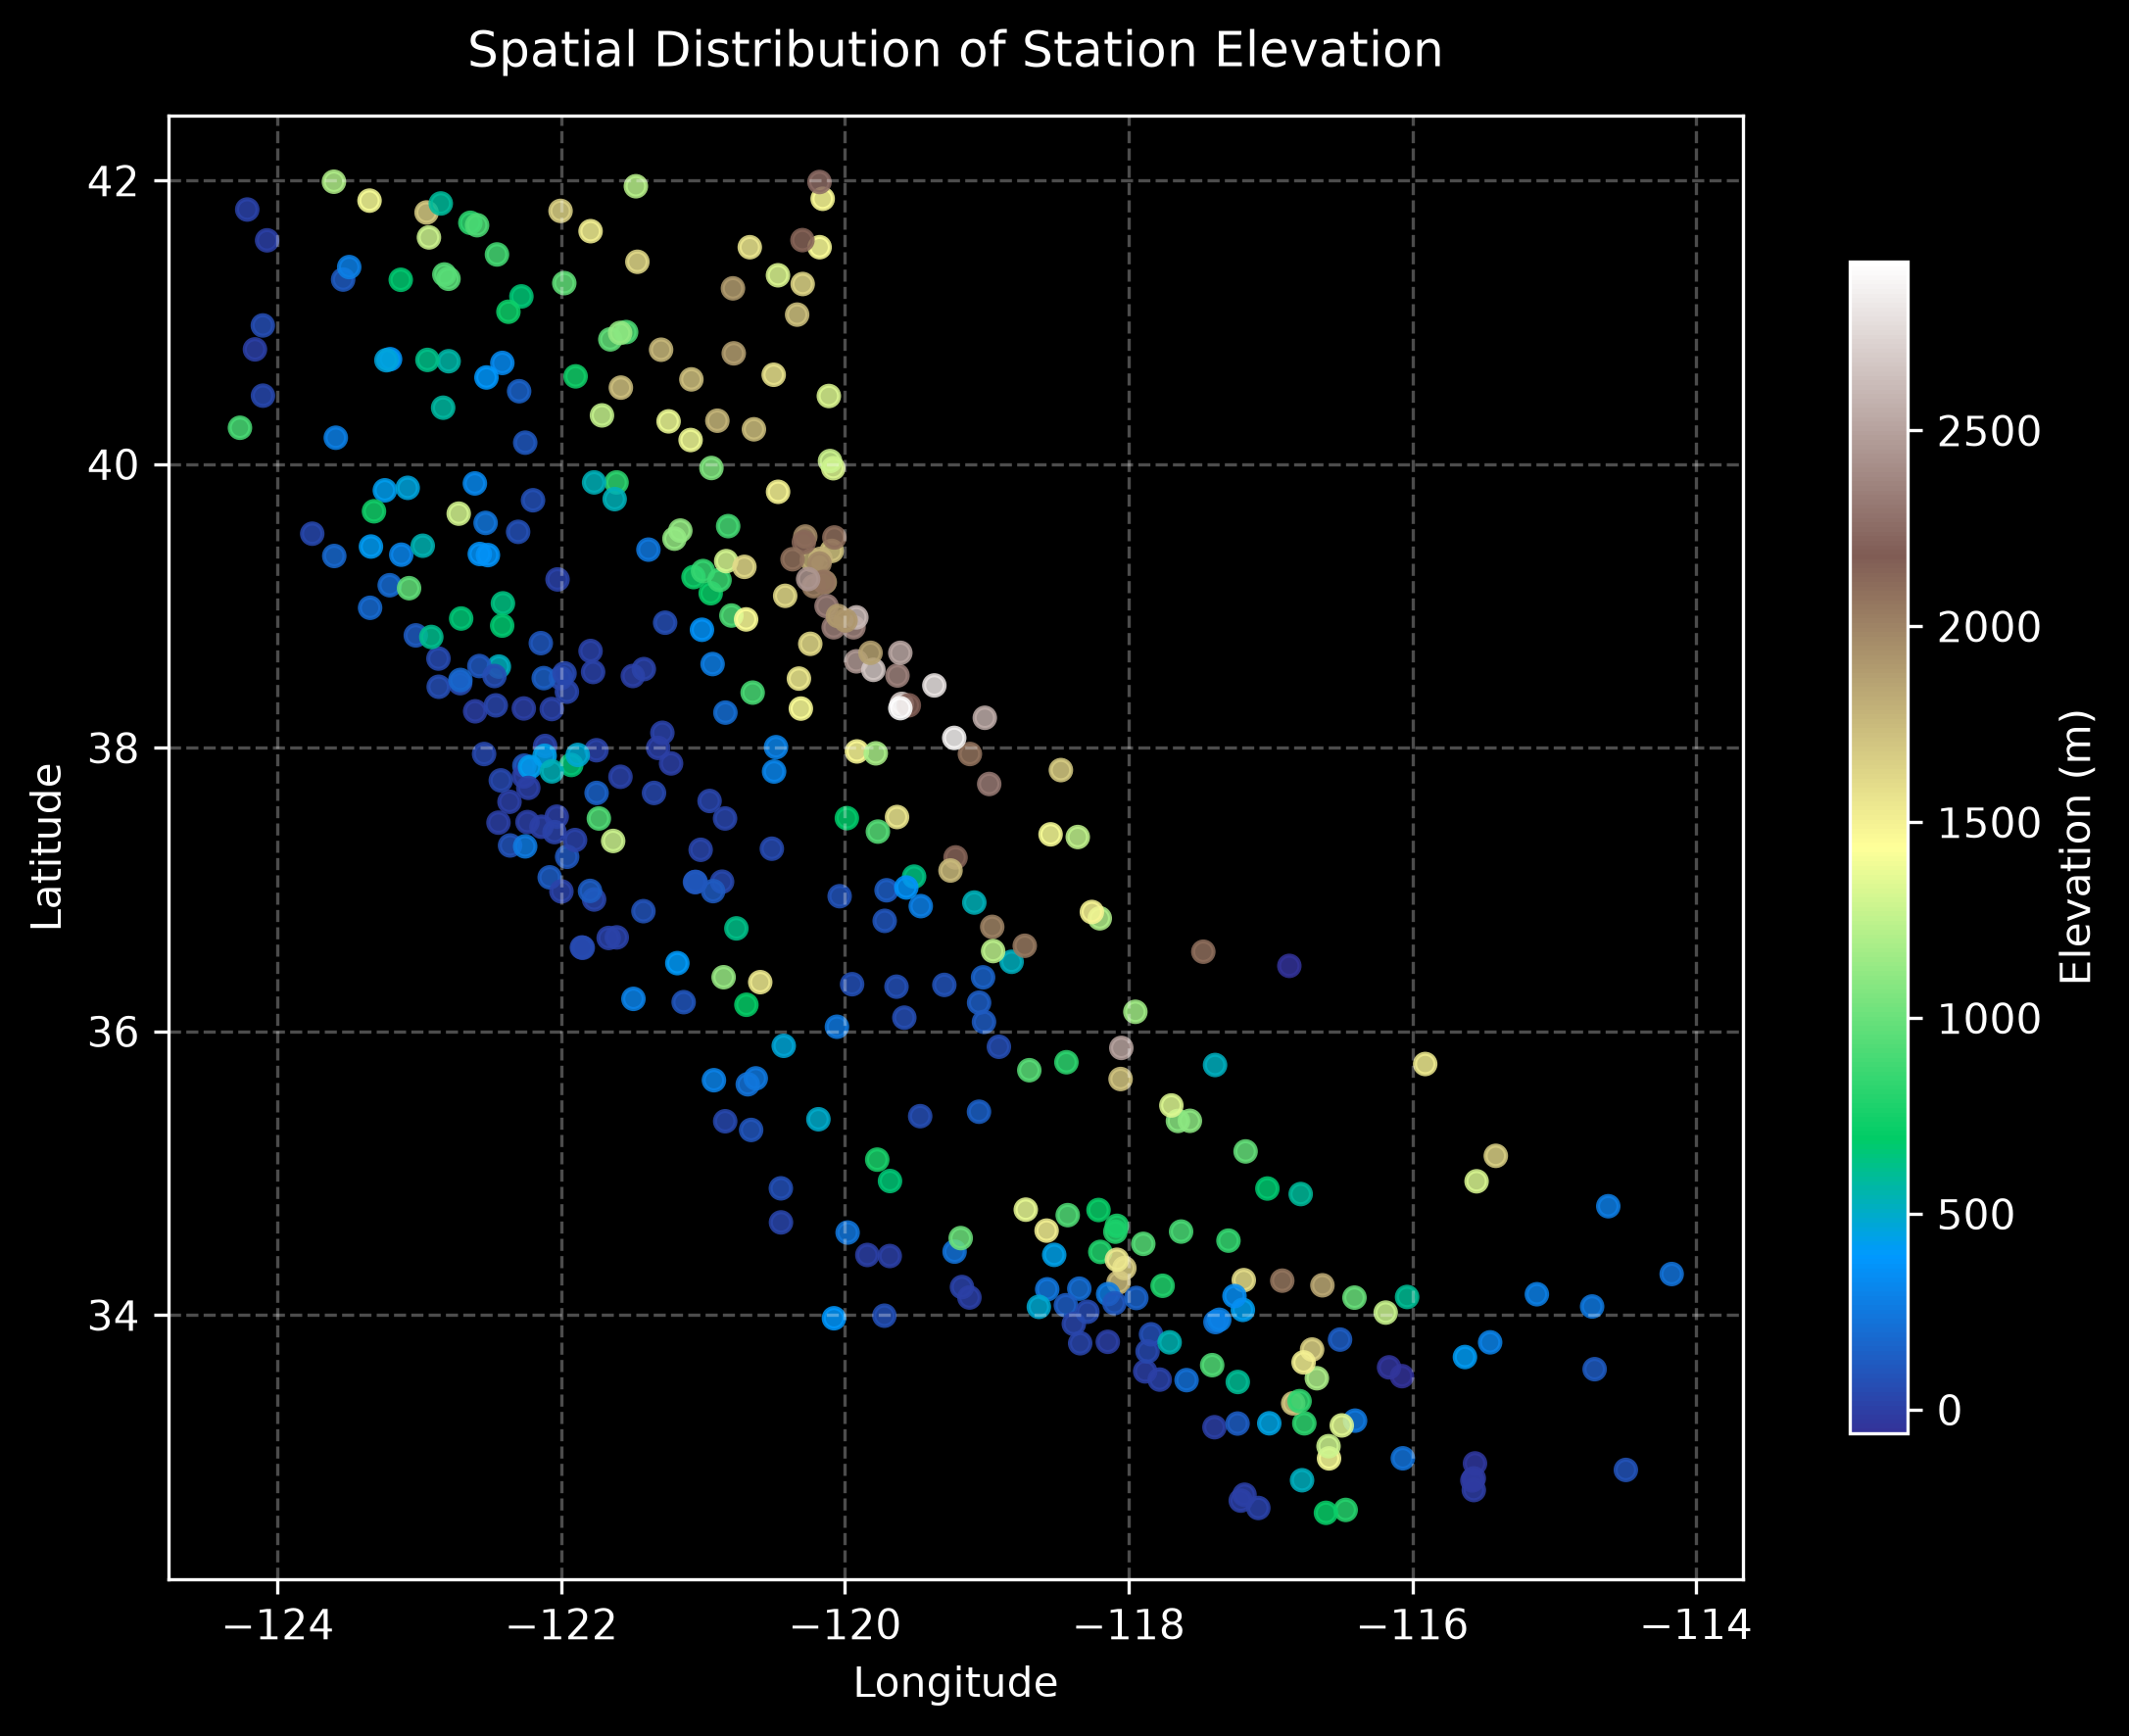

In [11]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point

# Aggregate data first for the map
station_data = (
    df.groupby('station_id')
    .agg(
        {
            'latitude': 'first',
            'longitude': 'first',
            'elevation_m': 'first',
            'TMAX_C': 'mean',
            'TMIN_C': 'mean',
        }
    )
    .reset_index()
)

gdf_stations = gpd.GeoDataFrame(
    station_data,
    geometry=[
        Point(xy) for xy in zip(station_data['longitude'], station_data['latitude'])
    ],
)

# ==========================================
# 1. MEAN TMAX MAP
# ==========================================
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

gdf_stations.plot(
    column='TMAX_C',
    ax=ax,
    legend=True,
    markersize=25,
    alpha=0.85,
    cmap='coolwarm',
    legend_kwds={
        'label': 'Mean Summer TMAX (°C)',
        'orientation': 'vertical',
        'shrink': 0.8,
    },
)

ax.set_title(
    'Spatial Distribution of Station Mean Summer TMAX', fontsize=12, pad=12
)
ax.set_xlabel('Longitude', fontsize=10)
ax.set_ylabel('Latitude', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
#plt.savefig(
#   'Figure_Map_Mean_TMAX.png', dpi=300, bbox_inches='tight', facecolor='black'
#)
plt.show()

# ==========================================
# 2. MEAN TMIN MAP
# ==========================================
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

gdf_stations.plot(
    column='TMIN_C',
    ax=ax,
    legend=True,
    markersize=25,
    alpha=0.85,
    cmap='coolwarm',
    legend_kwds={
        'label': 'Mean Summer TMIN (°C)',
        'orientation': 'vertical',
        'shrink': 0.8,
    },
)

ax.set_title(
    'Spatial Distribution of Station Mean Summer TMIN', fontsize=12, pad=12
)
ax.set_xlabel('Longitude', fontsize=10)
ax.set_ylabel('Latitude', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
#plt.savefig(
#    'Figure_Map_Mean_TMIN.png', dpi=300, bbox_inches='tight', facecolor='black'
#)
plt.show()

# ==========================================
# 3. ELEVATION MAP
# ==========================================
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

gdf_stations.plot(
    column='elevation_m',
    ax=ax,
    legend=True,
    markersize=25,
    alpha=0.85,
    cmap='terrain',
    legend_kwds={
        'label': 'Elevation (m)',
        'orientation': 'vertical',
        'shrink': 0.8,
    },
)

ax.set_title(
    'Spatial Distribution of Station Elevation', fontsize=12, pad=12
)
ax.set_xlabel('Longitude', fontsize=10)
ax.set_ylabel('Latitude', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
#plt.savefig(
#    'Figure_Map_Elevation.png', dpi=300, bbox_inches='tight', facecolor='black'
#)
plt.show()

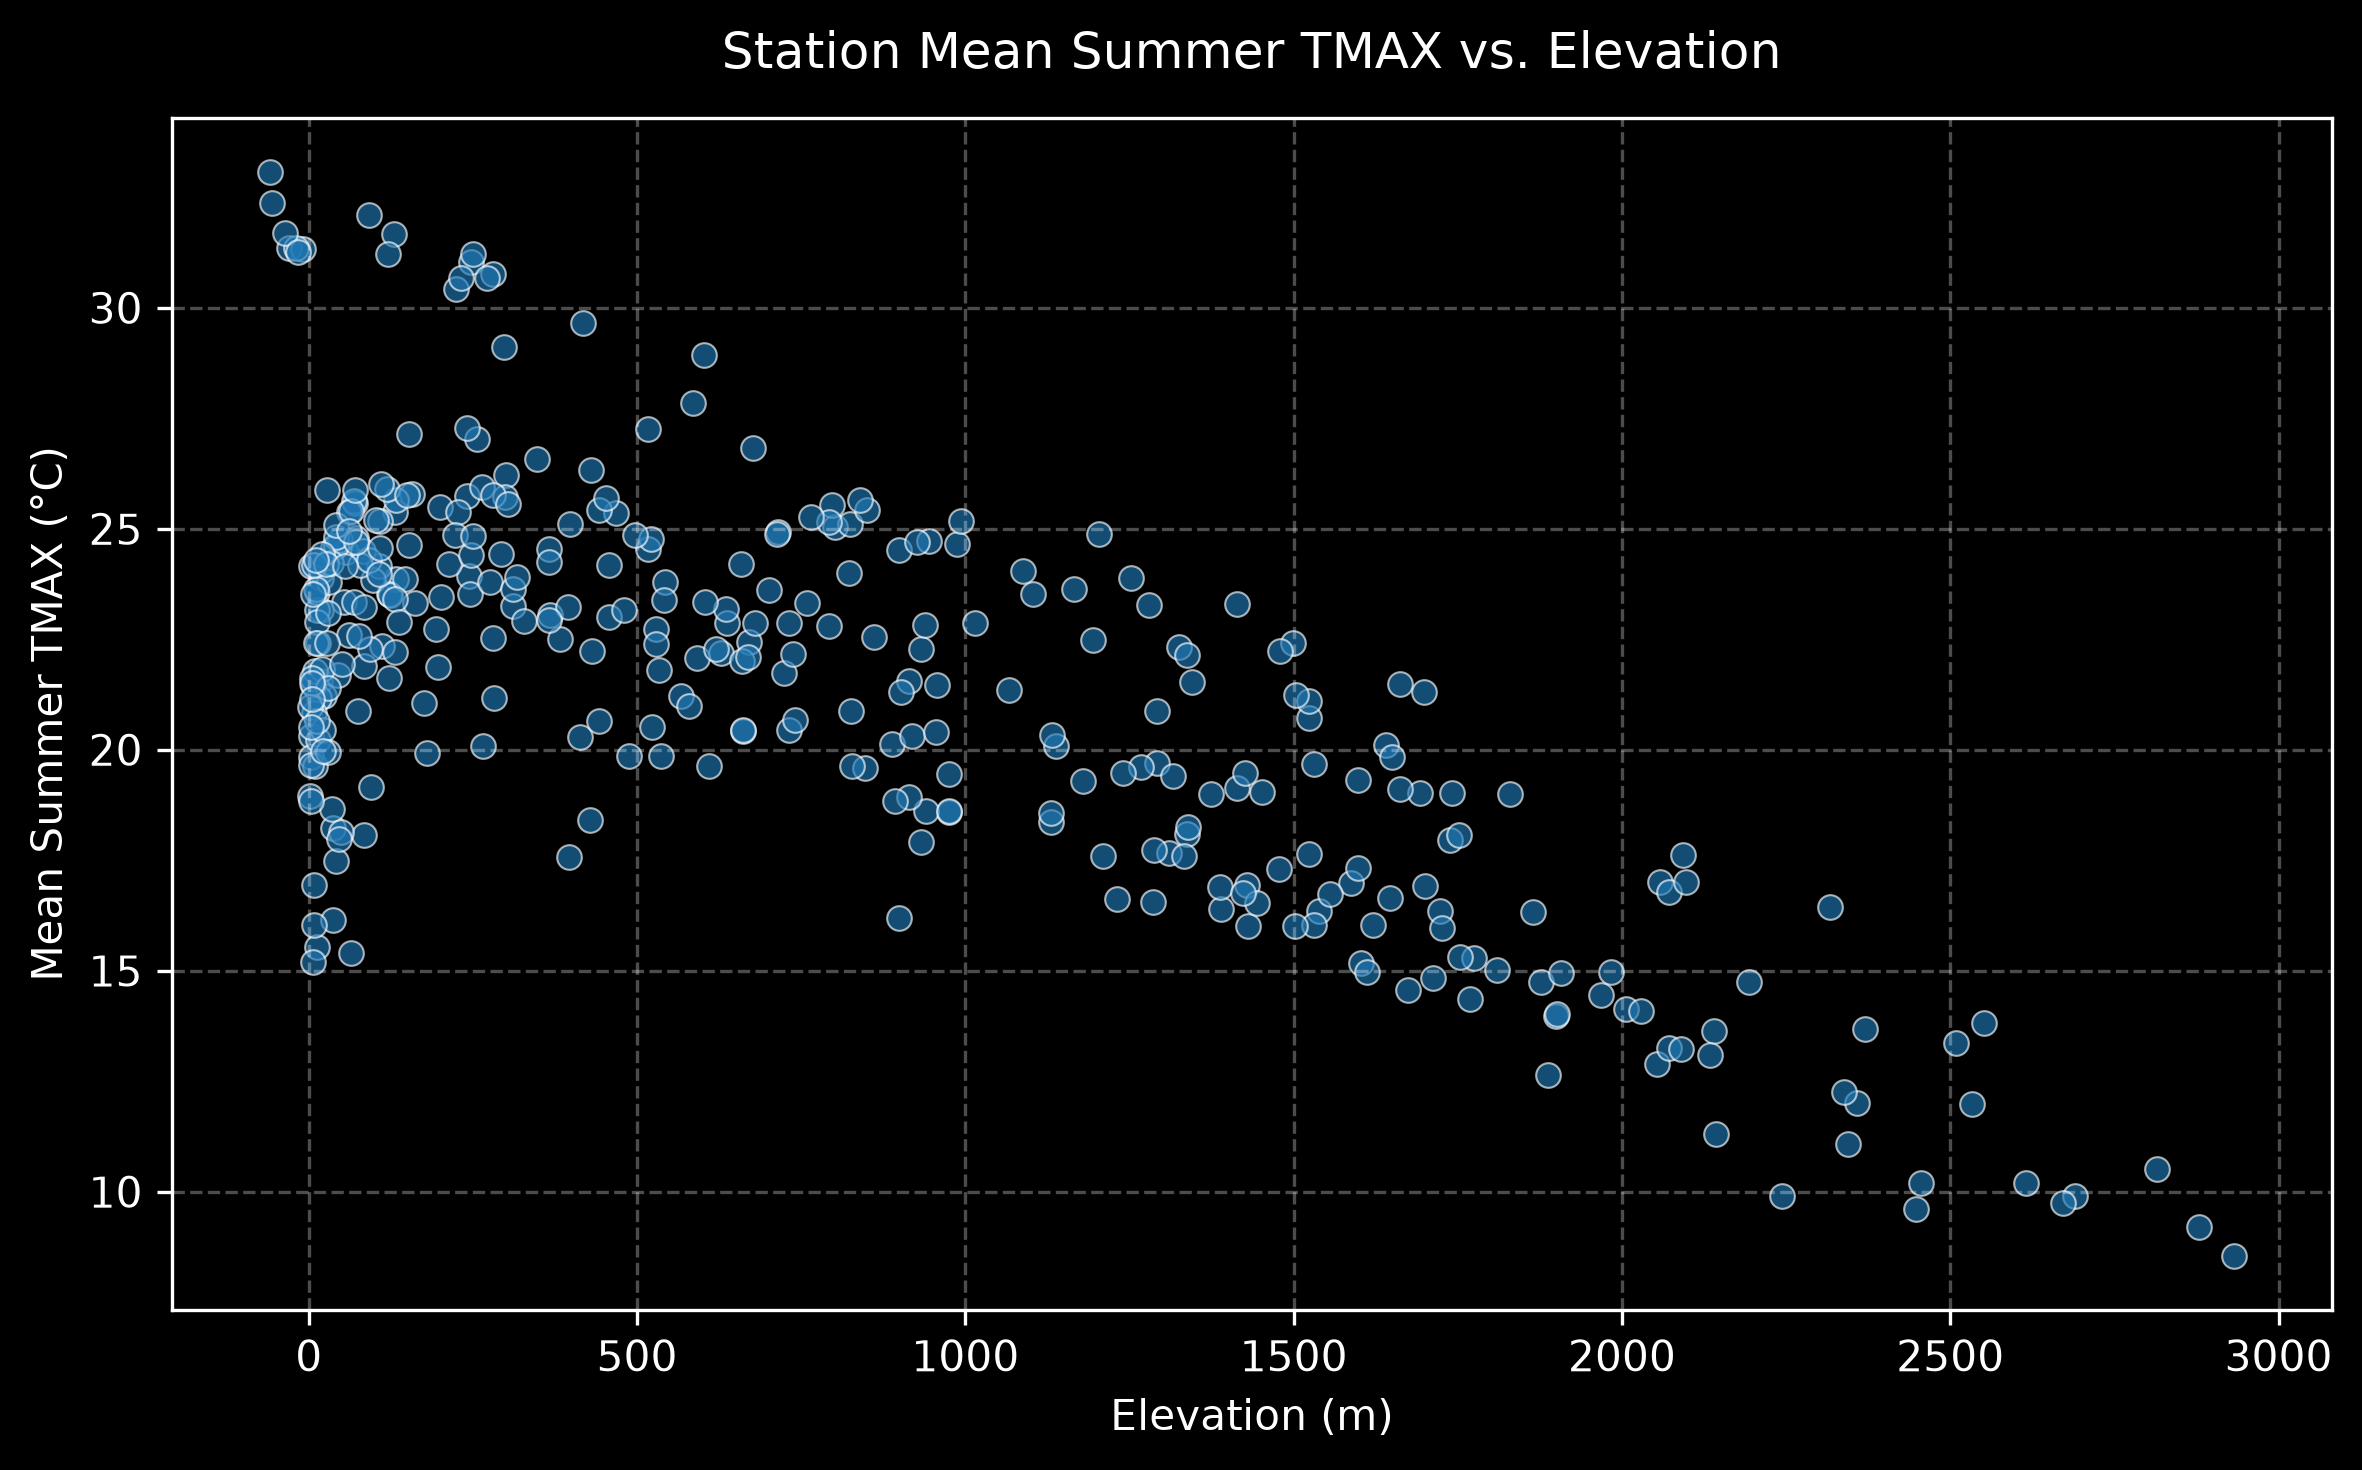

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

# Aggregate data for station-level statistics
station_stats = (
    df.groupby('station_id')
    .agg({'elevation_m': 'first', 'TMAX_C': 'mean'})
    .reset_index()
)

# Initialize figure with high print quality resolution
plt.figure(figsize=(8, 5), dpi=300)

# Generate polished scatterplot with professional markers
plt.scatter(
    station_stats['elevation_m'],
    station_stats['TMAX_C'],
    alpha=0.65,
    color='#1f77b4',
    edgecolor='white',
    linewidth=0.5,
    s=35,
)

# Formatting titles and labels
plt.title('Station Mean Summer TMAX vs. Elevation', fontsize=12, pad=12)
plt.xlabel('Elevation (m)', fontsize=10)
plt.ylabel('Mean Summer TMAX (°C)', fontsize=10)

# Clean grid styling and layout adjustments
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

# Save at high print quality
#plt.savefig(
 #   'Figure_Elevation_vs_TMAX.png',
 #   dpi=300,
 #   bbox_inches='tight'
#)
plt.show()

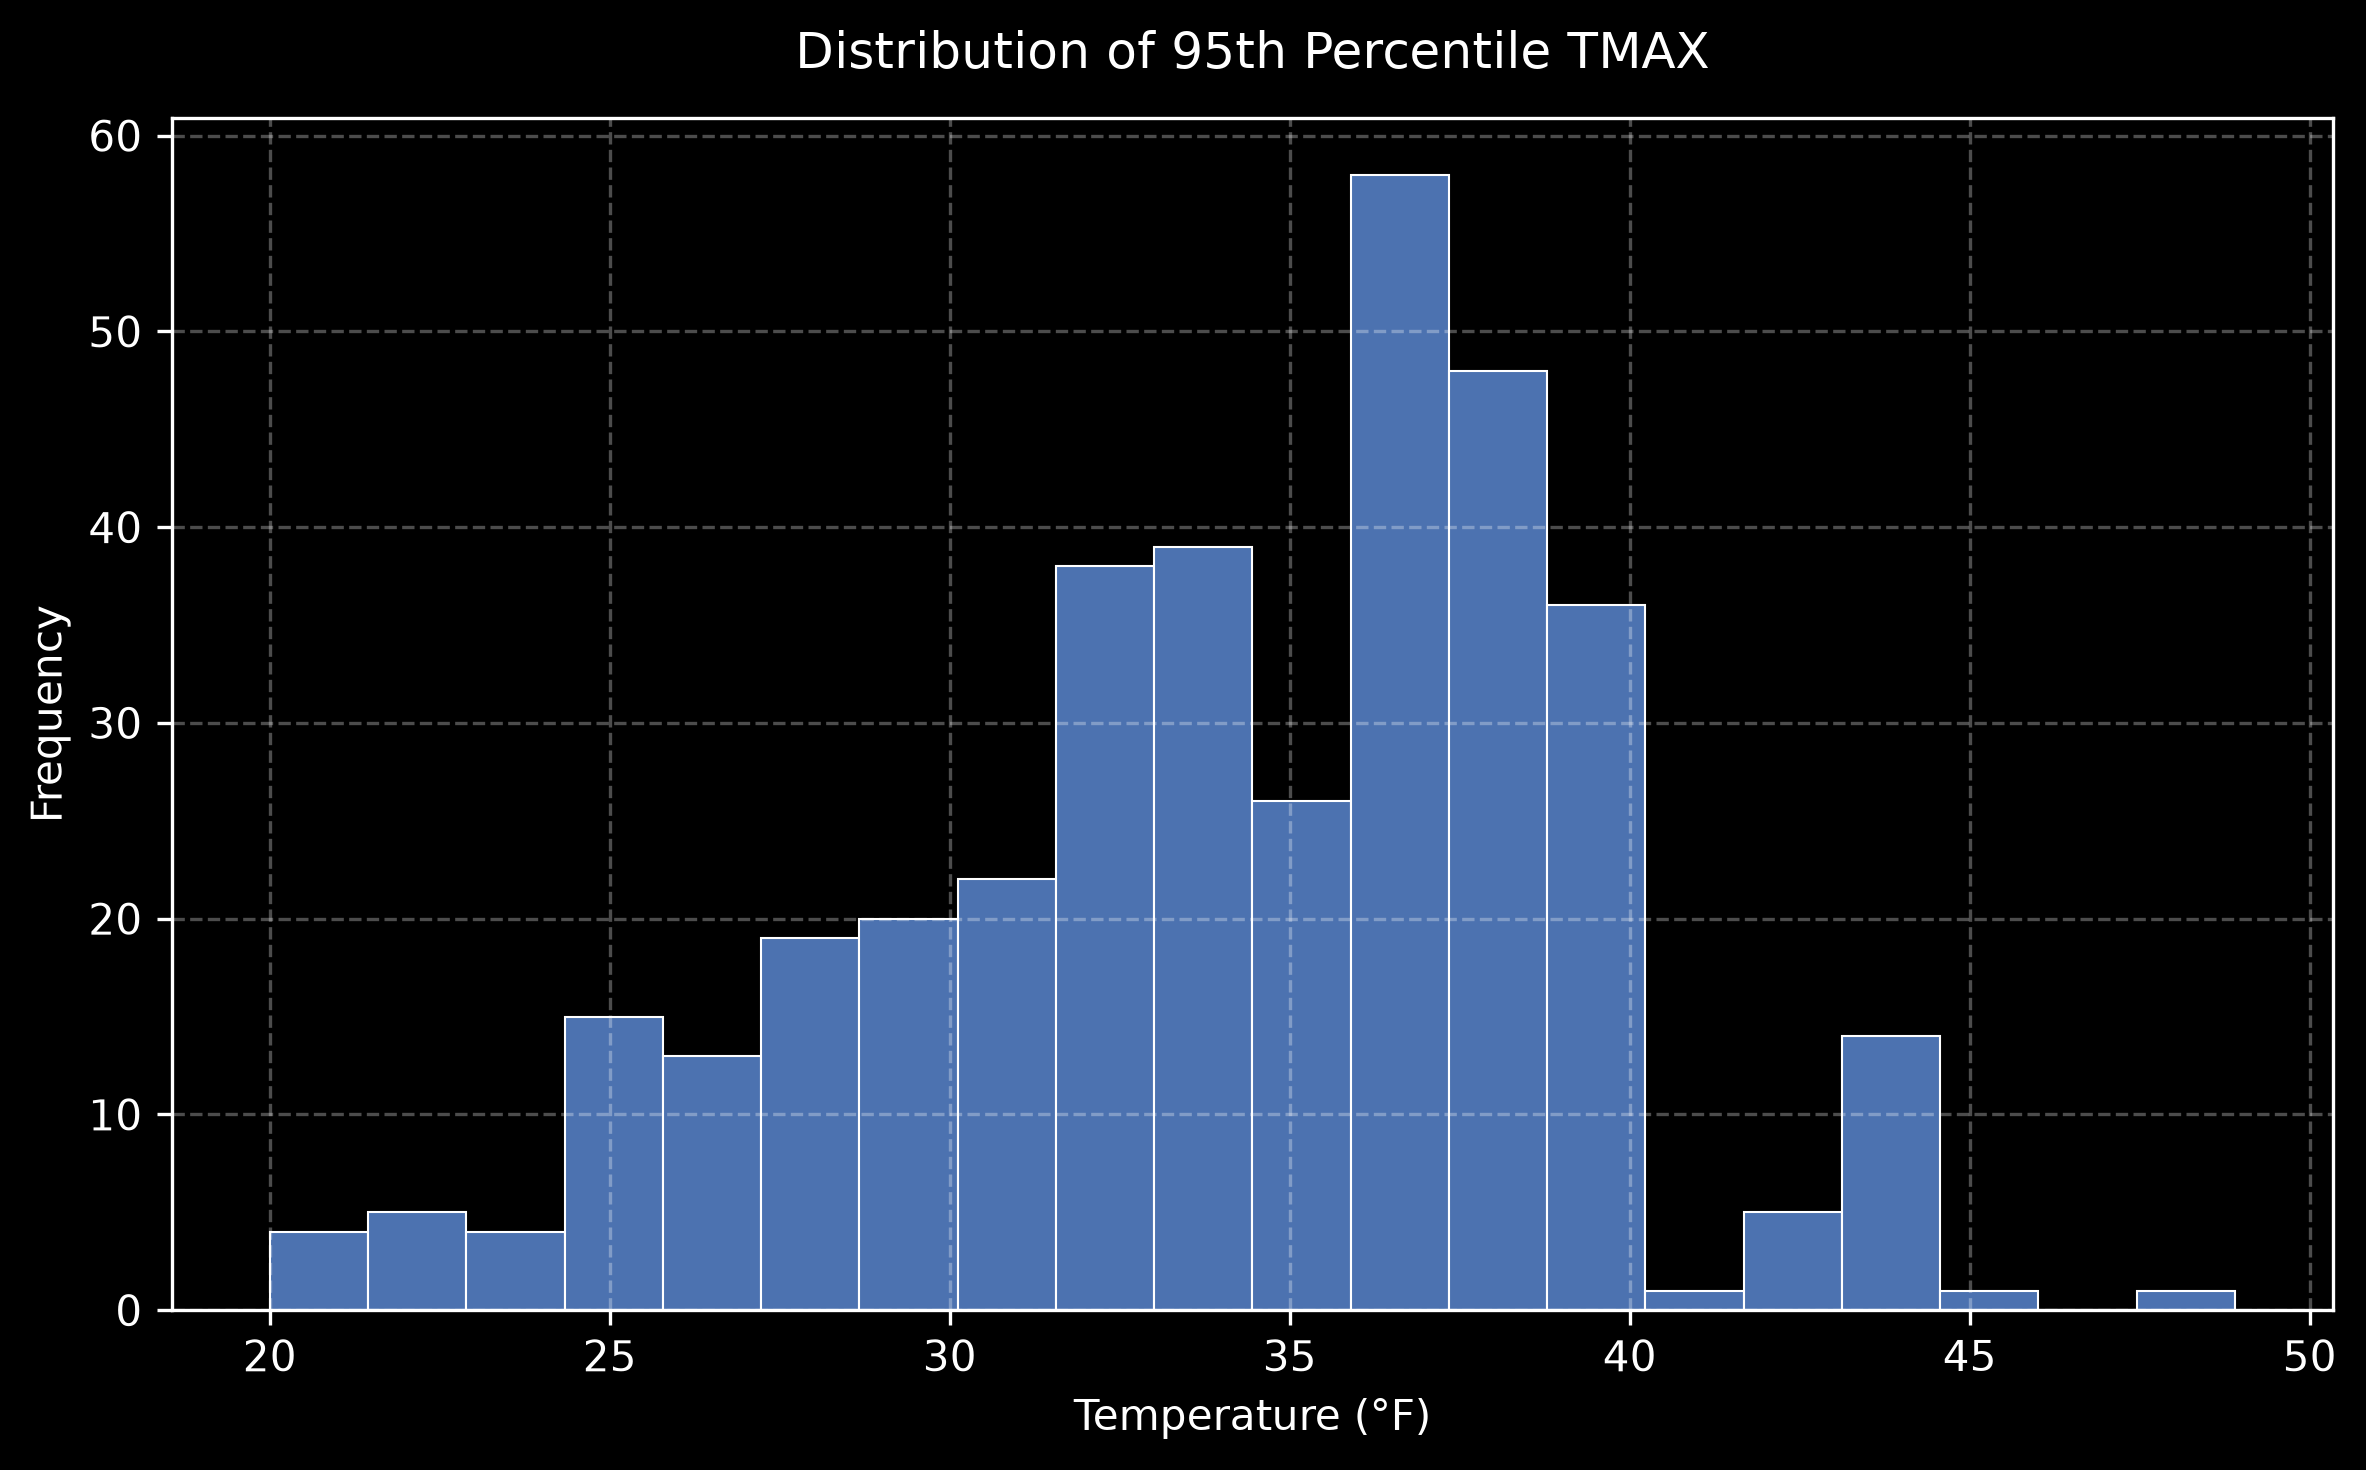

In [16]:
import matplotlib.pyplot as plt
import pandas as pd

# Calculate the 95th percentile per station in Fahrenheit
percentiles_f = df.groupby('station_id')[['TMAX_C', 'TMIN_C']].quantile(0.95)

# Initialize figure with high print quality resolution
plt.figure(figsize=(8, 5), dpi=300)

# Plot histogram with refined styling and borders
percentiles_f['TMAX_C'].hist(
    bins=20, color='#4c72b0', edgecolor='white', linewidth=0.5
)

# Formatting titles and labels
plt.title('Distribution of 95th Percentile TMAX', fontsize=12, pad=12)
plt.xlabel('Temperature (°F)', fontsize=10)
plt.ylabel('Frequency', fontsize=10)

# Clean grid styling and layout adjustments
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

# Save at high print quality
plt.savefig(
    'Figure_95th_Percentile_TMAX.png',
    dpi=300,
    bbox_inches='tight'
)
plt.show()

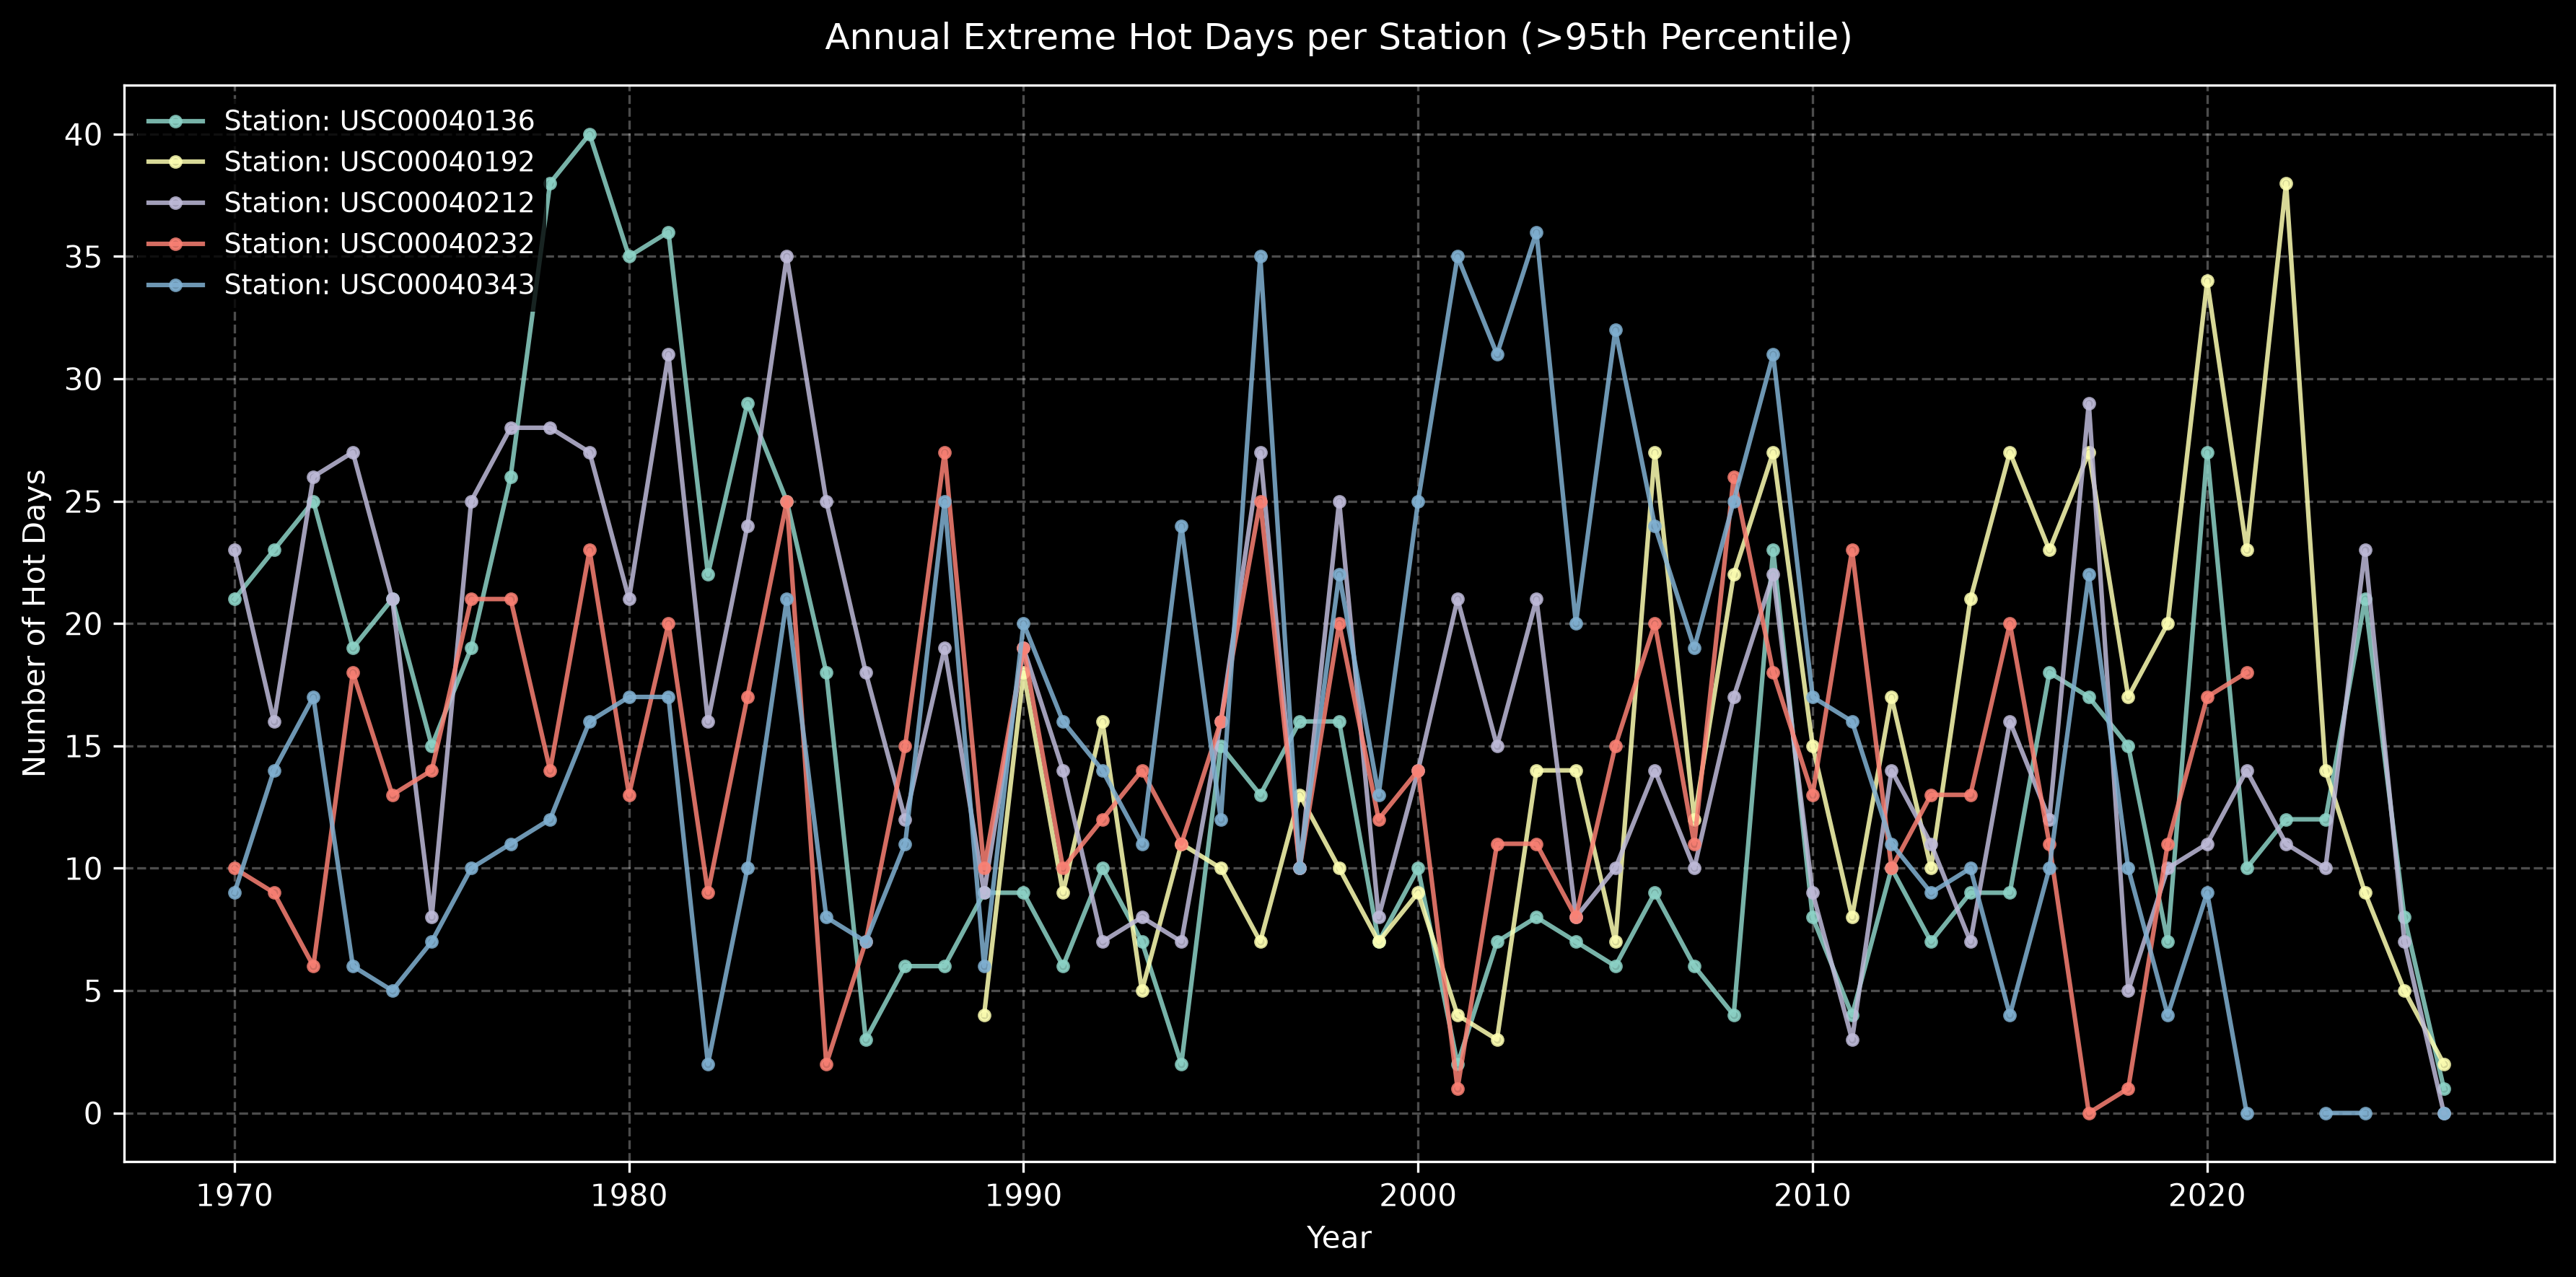

In [18]:
import matplotlib.pyplot as plt
import pandas as pd

# Calculate 95th percentile thresholds and identify hot days
thresholds_f = df.groupby('station_id')[['TMAX_C', 'TMIN_C']].quantile(0.95)
df_f = df.merge(thresholds_f, on='station_id', suffixes=('', '_95th'))
df_f['is_hot_day'] = df_f['TMAX_C'] > df_f['TMAX_C_95th']
yearly_extremes_f = df_f.groupby(['year', 'station_id'])[
    'is_hot_day'
].sum()

# Reshape data into a wide format and select the first 5 stations
plot_data = yearly_extremes_f.unstack().iloc[:, :5]

# Initialize figure with high print quality resolution
plt.figure(figsize=(12, 6), dpi=300)

# Plot each station's hot day trend with refined styling and markers
for col in plot_data.columns:
    plt.plot(
        plot_data.index,
        plot_data[col],
        label=f'Station: {col}',
        linewidth=1.5,
        marker='o',
        markersize=3.5,
        alpha=0.85,
    )

# Formatting titles and labels
plt.title('Annual Extreme Hot Days per Station (>95th Percentile)', fontsize=12, pad=12)
plt.xlabel('Year', fontsize=10)
plt.ylabel('Number of Hot Days', fontsize=10)

# Clean grid styling and layout adjustments
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(frameon=True, facecolor='black', edgecolor='none', fontsize=9)
plt.tight_layout()

# Save at high print quality
#plt.savefig(
#    'Figure_Extreme_Hot_Days.png',
#    dpi=300,
#    bbox_inches='tight'
#)
plt.show()